In [1]:

# ==========================================================================================
# CATTLE IDENTIFICATION FROM MUZZLE/FACE — Reimplementation of:
# "Attention-based multi-modal robust cattle identification technique using deep learning"
# (Pathak & Prakash, 2025, Computers and Electronics in Agriculture)
#
# This script is written as a sequence of Kaggle-notebook cells (marked with "# %%").
# Copy each "# %%" block into its own Kaggle cell, or just run the whole .py file.
#
# Assumes the author's pre-cropped, pre-split dataset, e.g.:
#   /kaggle/input/datasets/prashantpathak26/cmpd568m/Split/train/001/*.jpg
#   /kaggle/input/datasets/prashantpathak26/cmpd568m/Split/val/001/*.jpg
#   /kaggle/input/datasets/prashantpathak26/cmpd568m/Split/test/001/*.jpg
# (already muzzle-cropped -> no YOLOv8 detector step needed for this dataset)
#
# Pipeline implemented:
#   1. Data loading + augmentation (matches paper: ±15° rotation, on-the-fly augment on train only)
#   2. EfficientNetV2B0 backbone (ImageNet-1k weights) + custom Spatial Attention module
#      (avg-pool + max-pool along channel axis -> concat -> 7x7 conv -> sigmoid -> multiply)
#   3. Two-phase transfer learning:
#        Phase 1: backbone fully frozen, train only the classification head
#        Phase 2: unfreeze last 3 conv layers of backbone (as in paper's best config: PT+FT[:-3]+SA)
#   4. Metrics: accuracy, precision, recall, F1, ROC-AUC, bootstrap 95% CI, confusion matrix
#   5. Grad-CAM explainability
#   6. Optional: face+muzzle score-based fusion identification (Algorithm 1 of the paper)
#
# Framework: TensorFlow / Keras 2.x (as used in the paper). Tested config for Kaggle GPU (T4/P100).
# ==========================================================================================

In [2]:
#%% [Cell 1] ---------------------------------------------------------------------------------
# Environment check & imports
import os
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize
 
print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))
 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
 
 
# %% [Cell 1b] --------------------------------------------------------------------------------
# ------------------------------- GPU UTILIZATION SETUP -----------------------------------------
# `ImageDataGenerator.flow_from_directory` is the #1 reason for low GPU usage: it augments/decodes
# images in a single-threaded Python loop on CPU, so the GPU idles waiting for each batch. Fixes:
#   1. Mixed precision -> lets Tensor Cores run fp16 matmuls (T4/P100/A100 all support this on Kaggle)
#   2. XLA JIT compilation -> fuses ops, usually a free 10-20% speedup
#   3. Bigger batch size -> more work queued per GPU call (see CFG.BATCH_SIZE below, raise it)
#   4. Switch the data pipeline itself to tf.data (Cell 3 replacement) -> multi-threaded decode +
#      prefetching so the CPU prepares batch N+1 while the GPU trains on batch N.
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass  # must be set before GPUs are initialized; ignore if already initialized
 
tf.config.optimizer.set_jit(True)  # XLA
 
keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", keras.mixed_precision.global_policy())
# NOTE: with mixed precision, the final Dense layer must output float32 for numerical stability.
# build_model() below already sets dtype="float32" on the output layer for this reason.
 

TensorFlow: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [3]:
# %% [Cell 2] ---------------------------------------------------------------------------------
# ------------------------------- CONFIG (edit these) -----------------------------------------
class CFG:
    # Root of the split dataset. Change FEATURE_NAME to "face" if you point this at a face split.
    FEATURE_NAME = "muzzle"          # "muzzle" or "face" — only used for naming outputs
    DATA_ROOT = "/kaggle/input/datasets/prashantpathak26/cmpd568m/Split"
    TRAIN_DIR = os.path.join(DATA_ROOT, "train")
    VAL_DIR   = os.path.join(DATA_ROOT, "val")
    TEST_DIR  = os.path.join(DATA_ROOT, "test")
 
    IMG_SIZE = (224, 224)
    # Paper uses batch_size=10 (their hardware was an 8GB-RAM CPU box, no GPU). On a Kaggle T4/P100
    # you can go much bigger without hurting accuracy — bump this to 32-64 to actually load the GPU.
    BATCH_SIZE = 64
    NUM_CLASSES = None               # inferred automatically from the train dir
 
    # Training schedule
    PHASE1_EPOCHS = 30               # frozen-backbone (head-only) training
    PHASE2_EPOCHS = 100              # fine-tuning last 3 conv blocks (paper: up to 100, early-stop 10)
    PHASE1_LR = 1e-3
    PHASE2_LR = 1e-4                 # lower LR for fine-tuning, standard practice
    DROPOUT = 0.5
    EARLY_STOP_PATIENCE = 10
 
    # Fine-tuning depth: number of trailing layers of the backbone to unfreeze in Phase 2.
    # Paper's best result = fine-tune last 3 conv layers ("PT + FT[:-3] + SA").
    FINE_TUNE_LAST_N_LAYERS = 3
 
    THRESHOLD = 85  # confidence threshold (theta) used in Algorithm 1 score-based fusion
 
    OUTPUT_DIR = "/kaggle/working/outputs"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
 
 
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
CFG.NUM_CLASSES = len(os.listdir(CFG.TRAIN_DIR))
print(f"Detected {CFG.NUM_CLASSES} classes for feature='{CFG.FEATURE_NAME}'")
 

Detected 568 classes for feature='muzzle'


In [4]:
# %% [Cell 3] ---------------------------------------------------------------------------------
# ------------------------------- DATA PIPELINE (tf.data — fast, GPU-saturating) ----------------
# Replaces ImageDataGenerator. image_dataset_from_directory decodes JPEGs with libjpeg-turbo on
# multiple CPU threads, augmentation runs as a fused graph op, and .prefetch(AUTOTUNE) means the
# next batch is being prepared on CPU *while* the GPU is still training on the current one — this
# alone is usually what fixes "low GPU utilization" symptoms far more than any model-side change.
AUTOTUNE = tf.data.AUTOTUNE
 
# Build once from disk to get the class list / counts (also gives you CLASS_INDICES like before).
_tmp_train = keras.utils.image_dataset_from_directory(
    CFG.TRAIN_DIR, image_size=CFG.IMG_SIZE, batch_size=CFG.BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED,
)
CLASS_NAMES = _tmp_train.class_names                     # sorted class-folder names, e.g. ["001", "002", ...]
CLASS_INDICES = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}
with open(os.path.join(CFG.OUTPUT_DIR, f"class_indices_{CFG.FEATURE_NAME}.json"), "w") as f:
    json.dump(CLASS_INDICES, f)
assert len(CLASS_NAMES) == CFG.NUM_CLASSES, "Class count mismatch between dirs — check split."
 
# Augmentation layers run ON-GPU as part of the graph (paper: rotation +-15deg on train only).
data_augmentation = keras.Sequential([
    layers.RandomRotation(15 / 360.0, fill_mode="nearest"),   # +-15 degrees
    layers.RandomFlip("horizontal"),                          # optional generalisation aid; remove
], name="augmentation")                                       # for an exact replica of the paper.
 
def _preprocess(image, label, training):
    image = keras.applications.efficientnet_v2.preprocess_input(image)
    if training:
        image = data_augmentation(image, training=True)
    return image, label
 
def make_dataset(directory, training):
    ds = keras.utils.image_dataset_from_directory(
        directory, image_size=CFG.IMG_SIZE, batch_size=CFG.BATCH_SIZE,
        label_mode="int", shuffle=training, seed=SEED if training else None,
    )
    ds = ds.map(lambda x, y: _preprocess(x, y, training), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.cache()             # dataset is small (a few thousand images) -> fits in RAM easily
    ds = ds.prefetch(AUTOTUNE)      # overlap CPU batch-prep with GPU compute
    return ds
 
train_ds = make_dataset(CFG.TRAIN_DIR, training=True)
val_ds   = make_dataset(CFG.VAL_DIR, training=False)
test_ds  = make_dataset(CFG.TEST_DIR, training=False)
 
# Keep the same variable names used later in the script (Cells 6,7,9 and the F1 callback all
# refer to train_gen/val_gen/test_gen) so nothing downstream needs to change.
train_gen, val_gen, test_gen = train_ds, val_ds, test_ds
 
# The old ImageDataGenerator exposed `.classes` and `.reset()`, used later for evaluation and by
# MacroMicroF1Callback. tf.data datasets don't have those, so we rebuild the same interface here.
def _extract_labels(ds):
    return np.concatenate([y.numpy() for _, y in ds], axis=0)
 
class _GenCompat:
    """Thin wrapper so `val_gen`/`test_gen` keep working with code written for ImageDataGenerator."""
    def __init__(self, ds):
        self._ds = ds
        self.classes = _extract_labels(ds)
    def reset(self):
        pass  # tf.data datasets are re-iterable already; nothing to do
    def __iter__(self):
        return iter(self._ds)
 
val_gen = _GenCompat(val_ds)
test_gen = _GenCompat(test_ds)
# train_gen stays as the raw tf.data.Dataset (train_ds) — model.fit() accepts it directly.
 
# model.predict()/model.fit() need the underlying tf.data.Dataset, not the wrapper, when called
# directly on val/test — the wrapper's `._ds` attribute holds it (used in Cells 6/7/9/5b below).

Found 4609 files belonging to 568 classes.


I0000 00:00:1787722344.563118      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787722344.566219      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4609 files belonging to 568 classes.
Found 1333 files belonging to 568 classes.
Found 1613 files belonging to 568 classes.


In [5]:
# %% [Cell 4] ---------------------------------------------------------------------------------
# ------------------------------- SPATIAL ATTENTION MODULE -------------------------------------
# Implements Eq. (7)-(9) of the paper:
#   F_avg, F_max = channel-wise avg/max pooling of feature map F
#   Ms(F) = sigmoid(conv7x7([F_avg, F_max]))
#   F'    = Ms(F) (x) F     (element-wise multiply)
class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = layers.Conv2D(
            filters=1, kernel_size=kernel_size, padding="same",
            activation="sigmoid", use_bias=False, name="spatial_attn_conv7x7"
        )
 
    def call(self, x):
        avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)   # F_avg  (H,W,1)
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)    # F_max  (H,W,1)
        concat = tf.concat([avg_pool, max_pool], axis=-1)      # (H,W,2)
        attn_map = self.conv(concat)                           # Ms(F)  (H,W,1)
        return x * attn_map                                    # F' = Ms(F) (x) F
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"kernel_size": self.kernel_size})
        return cfg

In [6]:
# %% [Cell 5] ---------------------------------------------------------------------------------
# ------------------------------- MODEL BUILDER -------------------------------------------------
def build_model(num_classes, img_size=CFG.IMG_SIZE, dropout=CFG.DROPOUT, freeze_backbone=True):
    """
    EfficientNetV2B0 backbone (ImageNet-1k weights) + Spatial Attention + classification head.
    Mirrors Fig. 3/Fig. 4 of the paper.
    """
    inputs = keras.Input(shape=(*img_size, 3))
 
    backbone = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
        pooling=None,
    )
    backbone.trainable = not freeze_backbone
 
    x = backbone.output                      # feature map from final conv block (Conv 1x1 in Fig.4)
    x = SpatialAttention(kernel_size=7, name="spatial_attention")(x)   # enhanced feature map F'
 
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn_head")(x)
    x = layers.Dropout(dropout, name="dropout_head")(x)
    # dtype="float32" here matters under mixed_float16 policy: softmax + loss are numerically
    # unstable in fp16, so the last layer is forced back to fp32 while everything before it runs fp16.
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions", dtype="float32")(x)
 
    model = keras.Model(inputs, outputs, name=f"EffNetV2B0_SpatialAttn_{CFG.FEATURE_NAME}")
    return model, backbone
 
 
def set_fine_tune_layers(backbone, last_n=3):
    """
    Unfreeze only the last `last_n` layers of the backbone (paper's PT + FT[:-3] setting).
    Everything else stays frozen so we keep most of the pre-trained ImageNet weights.
    """
    backbone.trainable = True
    for layer in backbone.layers[:-last_n]:
        layer.trainable = False
    for layer in backbone.layers[-last_n:]:
        layer.trainable = True
    return backbone
 
 
# %% [Cell 5b] --------------------------------------------------------------------------------
# ------------------------------- PER-EPOCH MACRO / MICRO / WEIGHTED F1 ------------------------
# Keras has no built-in multi-class F1, so this callback runs predictions on the val set at the
# end of every epoch and computes all three averages via sklearn.
#   - micro_f1    == overall accuracy for single-label multi-class problems (pooled TP/FP/FN)
#   - macro_f1    == unweighted mean of per-class F1 (best for spotting weak classes)
#   - weighted_f1 == per-class F1 weighted by support (what the paper reports as "F1-score")
# NOTE: this adds a full validation-set predict() call every epoch, so it will slow training down
# noticeably on 100-epoch runs. Set `every_n_epochs` > 1 below if you want to trade granularity
# for speed (e.g. every_n_epochs=5 still gives you a trend without the per-epoch cost).
class MacroMicroF1Callback(callbacks.Callback):
    def __init__(self, val_generator, every_n_epochs=1):
        super().__init__()
        self.val_generator = val_generator
        self.every_n_epochs = every_n_epochs
        self.history_f1 = {"epoch": [], "macro_f1": [], "micro_f1": [], "weighted_f1": []}
 
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs != 0:
            return
        y_true = self.val_generator.classes
        y_probs = self.model.predict(self.val_generator._ds, verbose=0)
        y_pred = np.argmax(y_probs, axis=1)
 
        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
 
        self.history_f1["epoch"].append(epoch + 1)
        self.history_f1["macro_f1"].append(macro_f1)
        self.history_f1["micro_f1"].append(micro_f1)
        self.history_f1["weighted_f1"].append(weighted_f1)
 
        if logs is not None:
            logs["val_macro_f1"] = macro_f1
            logs["val_micro_f1"] = micro_f1
            logs["val_weighted_f1"] = weighted_f1
 
        print(f" — val_macro_f1: {macro_f1:.4f} — val_micro_f1: {micro_f1:.4f} "
              f"— val_weighted_f1: {weighted_f1:.4f}")
 
 
# One shared instance so the F1 history is continuous across Phase 1 -> Phase 2.
f1_callback = MacroMicroF1Callback(val_gen, every_n_epochs=1)

In [7]:
# %% [Cell 6] ---------------------------------------------------------------------------------
# ------------------------------- PHASE 1: FROZEN BACKBONE (head-only) -------------------------
model, backbone = build_model(CFG.NUM_CLASSES, freeze_backbone=True)
model.summary()
 
model.compile(
    optimizer=optimizers.RMSprop(learning_rate=CFG.PHASE1_LR),   # paper uses RMSProp
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
 
phase1_ckpt_path = os.path.join(CFG.OUTPUT_DIR, f"phase1_best_{CFG.FEATURE_NAME}.keras")
phase1_callbacks = [
    callbacks.ModelCheckpoint(phase1_ckpt_path, monitor="val_accuracy", save_best_only=True, mode="max"),
    callbacks.EarlyStopping(monitor="val_accuracy", patience=CFG.EARLY_STOP_PATIENCE,
                             restore_best_weights=True, mode="max"),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    f1_callback,
]
 
history_phase1 = model.fit(
    train_gen,                    # tf.data.Dataset (train_ds) — Keras consumes this directly
    validation_data=val_gen._ds,  # unwrap the compat wrapper back to the raw tf.data.Dataset
    epochs=CFG.PHASE1_EPOCHS,
    callbacks=phase1_callbacks,
)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EffNetV2B0_SpatialAttn_muzzle"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,652,138 (25.38 MB)

 Trainable params: 730,266 (2.79 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

Epoch 1/30


I0000 00:00:1787650064.560242     232 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.0492 - loss: 6.1768 — val_macro_f1: 0.1643 — val_micro_f1: 0.3511 — val_weighted_f1: 0.2888
73/73 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.1222 - loss: 5.4703 - val_accuracy: 0.3511 - val_loss: 5.7117 - learning_rate: 0.0010 - val_macro_f1: 0.1643 - val_micro_f1: 0.3511 - val_weighted_f1: 0.2888
Epoch 2/30
71/73 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4095 - loss: 3.4067 — val_macro_f1: 0.4785 — val_micro_f1: 0.6392 — val_weighted_f1: 0.5854
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.4719 - loss: 3.0009 - val_accuracy: 0.6392 - val_loss: 4.3487 - learning_rate: 0.0010 - val_macro_f1: 0.4785 - val_micro_f1: 0.6392 - val_weighted_f1: 0.5854
Epoch 3/30
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6495 - loss: 1.9987 — val_macro_f1: 0.7117 — val_micro_f1: 0.8140 — val_weighted_f1: 0.7812
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.6902 - loss: 1.8072 - val_accuracy: 0.8140 - val_loss: 3.0412

In [8]:
# %% [Cell 7] ---------------------------------------------------------------------------------
# ------------------------------- PHASE 2: FINE-TUNE LAST 3 CONV LAYERS ------------------------
model.load_weights(phase1_ckpt_path)
backbone = set_fine_tune_layers(backbone, last_n=CFG.FINE_TUNE_LAST_N_LAYERS)
 
# double-check trainable layer count
trainable_layers = [l.name for l in backbone.layers if l.trainable]
print(f"Unfrozen backbone layers ({len(trainable_layers)}):", trainable_layers)
 
model.compile(
    optimizer=optimizers.RMSprop(learning_rate=CFG.PHASE2_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
 
phase2_ckpt_path = os.path.join(CFG.OUTPUT_DIR, f"phase2_best_{CFG.FEATURE_NAME}.keras")
phase2_callbacks = [
    callbacks.ModelCheckpoint(phase2_ckpt_path, monitor="val_accuracy", save_best_only=True, mode="max"),
    callbacks.EarlyStopping(monitor="val_accuracy", patience=CFG.EARLY_STOP_PATIENCE,
                             restore_best_weights=True, mode="max"),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    f1_callback,
]
 
history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen._ds,
    epochs=CFG.PHASE2_EPOCHS,
    callbacks=phase2_callbacks,
)
 
model.load_weights(phase2_ckpt_path)
final_model_path = os.path.join(CFG.OUTPUT_DIR, f"final_model_{CFG.FEATURE_NAME}.keras")
model.save(final_model_path)
print("Saved final model to:", final_model_path)
 

Unfrozen backbone layers (3): ['top_conv', 'top_bn', 'top_activation']
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9921 - loss: 0.0369 — val_macro_f1: 0.9398 — val_micro_f1: 0.9602 — val_weighted_f1: 0.9544
73/73 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.9931 - loss: 0.0352 - val_accuracy: 0.9602 - val_loss: 0.2329 - learning_rate: 1.0000e-04 - val_macro_f1: 0.9398 - val_micro_f1: 0.9602 - val_weighted_f1: 0.9544
Epoch 2/100
71/73 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9960 - loss: 0.0259 — val_macro_f1: 0.9608 — val_micro_f1: 0.9760 — val_weighted_f1: 0.9718
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.9957 - loss: 0.0279 - val_accuracy: 0.9760 - val_loss: 0.1765 - learning_rate: 1.0000e-04 - val_macro_f1: 0.9608 - val_micro_f1: 0.9760 - val_weighted_f1: 0.9718
Epoch 3/100
71/73 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9958 - loss: 0.0246 — val_macro_f1: 0.9636 — val_micro_f1: 0.9782 — val_weighted_f1: 0.9745
73/73 ━━━━━━━━━━━━━━━━

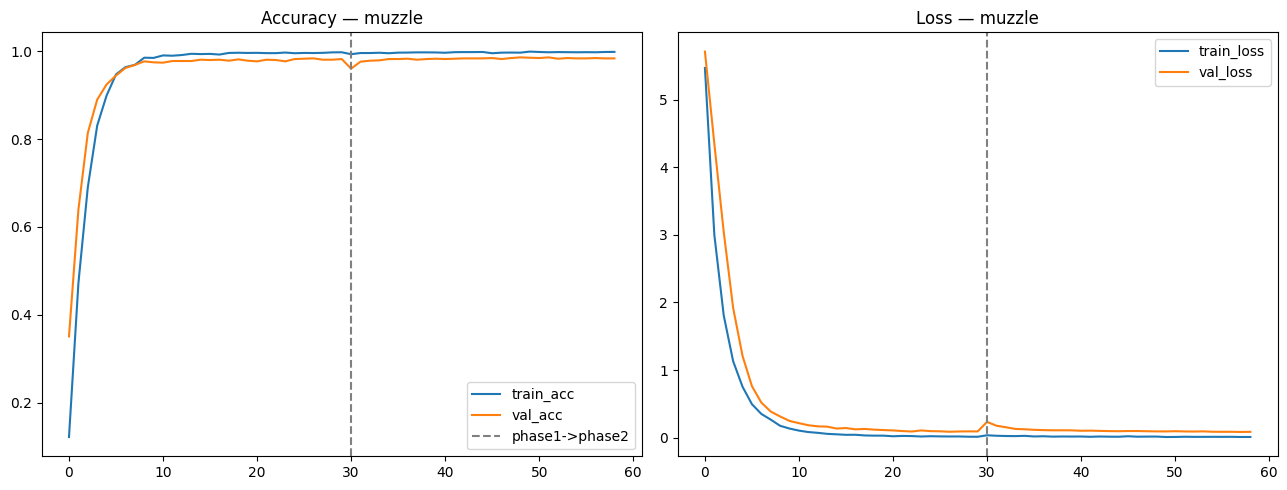

In [9]:
# %% [Cell 8] ---------------------------------------------------------------------------------
# ------------------------------- TRAINING CURVES -----------------------------------------------
def plot_history(h1, h2, feature_name):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]
    split_epoch = len(h1.history["accuracy"])
 
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(acc, label="train_acc")
    axes[0].plot(val_acc, label="val_acc")
    axes[0].axvline(split_epoch, color="gray", linestyle="--", label="phase1->phase2")
    axes[0].set_title(f"Accuracy — {feature_name}")
    axes[0].legend()
 
    axes[1].plot(loss, label="train_loss")
    axes[1].plot(val_loss, label="val_loss")
    axes[1].axvline(split_epoch, color="gray", linestyle="--")
    axes[1].set_title(f"Loss — {feature_name}")
    axes[1].legend()
 
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"training_curves_{feature_name}.png"), dpi=150)
    plt.show()
 
plot_history(history_phase1, history_phase2, CFG.FEATURE_NAME)
 

In [10]:
# %% [Cell 9] ---------------------------------------------------------------------------------
# ------------------------------- EVALUATION ON TEST SET ----------------------------------------
y_true = test_gen.classes
y_probs = model.predict(test_gen._ds, verbose=1)
y_pred = np.argmax(y_probs, axis=1)
 
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
 
# Macro / micro F1 on the held-out test set (paper only reports weighted — these give you the
# unweighted-per-class view (macro) and the pooled view (micro, == accuracy here) as well).
macro_f1_test = f1_score(y_true, y_pred, average="macro", zero_division=0)
micro_f1_test = f1_score(y_true, y_pred, average="micro", zero_division=0)
 
# Multi-class ROC-AUC (one-vs-rest, weighted) — mirrors paper's ROC-AUC reporting
y_true_bin = label_binarize(y_true, classes=list(range(CFG.NUM_CLASSES)))
try:
    roc_auc = roc_auc_score(y_true_bin, y_probs, average="weighted", multi_class="ovr")
except ValueError:
    roc_auc = float("nan")  # can happen if a class has zero test samples
 
print(f"[{CFG.FEATURE_NAME}] Accuracy:    {acc*100:.2f}%")
print(f"[{CFG.FEATURE_NAME}] Precision:   {prec*100:.2f}%  (weighted)")
print(f"[{CFG.FEATURE_NAME}] Recall:      {rec*100:.2f}%  (weighted)")
print(f"[{CFG.FEATURE_NAME}] F1 weighted: {f1*100:.2f}%")
print(f"[{CFG.FEATURE_NAME}] F1 macro:    {macro_f1_test*100:.2f}%")
print(f"[{CFG.FEATURE_NAME}] F1 micro:    {micro_f1_test*100:.2f}%  (== accuracy for single-label multi-class)")
print(f"[{CFG.FEATURE_NAME}] ROC-AUC:     {roc_auc:.4f}")
 
report = classification_report(y_true, y_pred, target_names=list(CLASS_INDICES.keys()), zero_division=0)
with open(os.path.join(CFG.OUTPUT_DIR, f"classification_report_{CFG.FEATURE_NAME}.txt"), "w") as f:
    f.write(report)
 

26/26 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step 
[muzzle] Accuracy:    97.52%
[muzzle] Precision:   97.79%  (weighted)
[muzzle] Recall:      97.52%  (weighted)
[muzzle] F1 weighted: 97.27%
[muzzle] F1 macro:    96.14%
[muzzle] F1 micro:    97.52%  (== accuracy for single-label multi-class)
[muzzle] ROC-AUC:     0.9998


In [11]:
# %% [Cell 10] --------------------------------------------------------------------------------
# ------------------------------- BOOTSTRAP 95% CONFIDENCE INTERVAL ----------------------------
# Mirrors Eq. (10) of the paper: bootstrap resampling of the test predictions.
def bootstrap_accuracy_ci(y_true, y_pred, n_bootstrap=1000, ci=95, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    accs = np.empty(n_bootstrap)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    for i in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        accs[i] = accuracy_score(y_true[idx], y_pred[idx])
    lower = np.percentile(accs, (100 - ci) / 2)
    upper = np.percentile(accs, 100 - (100 - ci) / 2)
    return lower, upper, accs
 
ci_lower, ci_upper, boot_accs = bootstrap_accuracy_ci(y_true, y_pred)
print(f"[{CFG.FEATURE_NAME}] 95% CI (bootstrap): [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
 

[muzzle] 95% CI (bootstrap): [96.71%, 98.20%]


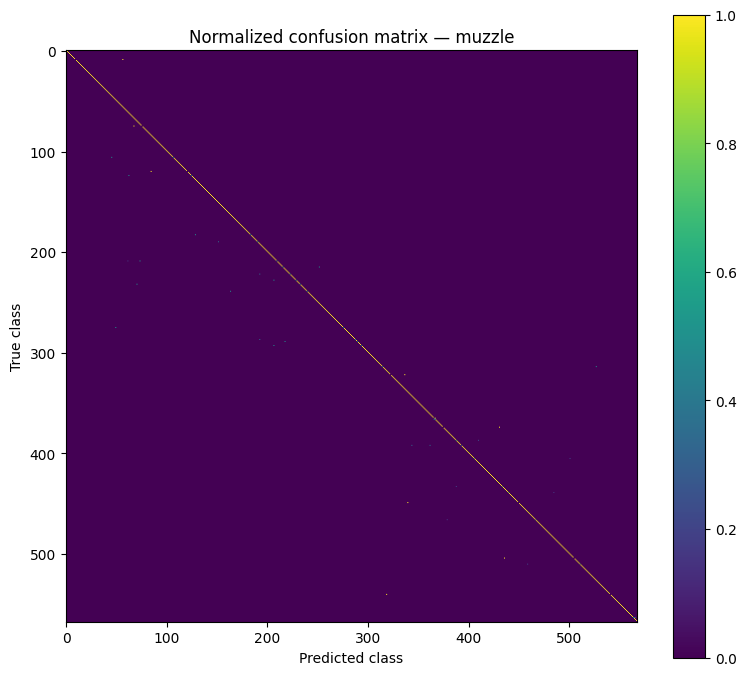

In [ ]:
# %% [Cell 11] --------------------------------------------------------------------------------
# ------------------------------- CONFUSION MATRIX ----------------------------------------------
cm = confusion_matrix(y_true, y_pred, normalize="true")
plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="viridis")
plt.title(f"Normalized confusion matrix — {CFG.FEATURE_NAME}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"confusion_matrix_{CFG.FEATURE_NAME}.png"), dpi=150)
plt.show()
 

In [ ]:
# %% [Cell 12] --------------------------------------------------------------------------------
# ------------------------------- GRAD-CAM EXPLAINABILITY ---------------------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = keras.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
 
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()
 
 
def show_gradcam(img_path, model, last_conv_layer_name="spatial_attention", alpha=0.4):
    img = keras.preprocessing.image.load_img(img_path, target_size=CFG.IMG_SIZE)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_batch = keras.applications.efficientnet_v2.preprocess_input(img_batch.copy())
 
    heatmap = make_gradcam_heatmap(img_batch, model, last_conv_layer_name)
    heatmap = np.uint8(255 * heatmap)
 
    import matplotlib.cm as cm_mod
    jet = cm_mod.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_array.shape[1], img_array.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
 
    superimposed = jet_heatmap * alpha + img_array
    superimposed = keras.preprocessing.image.array_to_img(superimposed)
 
    plt.figure(figsize=(5, 5))
    plt.imshow(superimposed)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.show()
    return superimposed
 
# Example usage (uncomment and point to a real test image — tf.data doesn't expose .filepaths
# the way ImageDataGenerator did, so just grab any file path directly off disk):
# import glob
# sample_path = glob.glob(os.path.join(CFG.TEST_DIR, "*", "*.jpg"))[0]
# show_gradcam(sample_path, model, last_conv_layer_name="spatial_attention")
 

In [ ]:
# %% [Cell 13] --------------------------------------------------------------------------------
# ------------------------------- ABLATION HELPER (optional) ------------------------------------
# Runs the same two-phase recipe for different fine-tune depths / with-without spatial attention,
# so you can reproduce Table 8 of the paper if you want the full ablation grid.
def run_ablation_variant(last_n_layers, use_spatial_attention=True, epochs_p2=30, tag="variant"):
    m, bb = build_model(CFG.NUM_CLASSES, freeze_backbone=True)
    if not use_spatial_attention:
        # Rebuild without the SpatialAttention layer for a fair "no-SA" comparison
        inputs = keras.Input(shape=(*CFG.IMG_SIZE, 3))
        backbone_noattn = keras.applications.EfficientNetV2B0(
            include_top=False, weights="imagenet", input_tensor=inputs)
        backbone_noattn.trainable = False
        x = layers.GlobalAveragePooling2D()(backbone_noattn.output)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(CFG.DROPOUT)(x)
        outputs = layers.Dense(CFG.NUM_CLASSES, activation="softmax")(x)
        m = keras.Model(inputs, outputs)
        bb = backbone_noattn
 
    m.compile(optimizer=optimizers.RMSprop(CFG.PHASE1_LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(train_gen, validation_data=val_gen._ds, epochs=10,
          callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                              restore_best_weights=True, mode="max")])
 
    bb = set_fine_tune_layers(bb, last_n=last_n_layers)
    m.compile(optimizer=optimizers.RMSprop(CFG.PHASE2_LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = m.fit(train_gen, validation_data=val_gen._ds, epochs=epochs_p2,
                 callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=CFG.EARLY_STOP_PATIENCE,
                                                     restore_best_weights=True, mode="max")])
 
    val_acc = max(hist.history["val_accuracy"])
    print(f"[{tag}] last_n={last_n_layers}, SA={use_spatial_attention} -> best val_acc={val_acc*100:.2f}%")
    return m, val_acc
 
# Example (uncomment to run a subset of the ablation grid):
# run_ablation_variant(last_n_layers=1, use_spatial_attention=True, tag="FT-1+SA")
# run_ablation_variant(last_n_layers=3, use_spatial_attention=False, tag="FT-3+NoAttn")
 

In [ ]:
# %% [Cell 14] --------------------------------------------------------------------------------
# ------------------------------- MULTI-MODAL SCORE FUSION (Algorithm 1) -----------------------
# Only meaningful if you've trained BOTH a muzzle model and a face model.
# Loads two saved models and applies the paper's threshold-based fusion rule.
def predict_with_confidence(model, img_path, img_size=CFG.IMG_SIZE):
    img = keras.preprocessing.image.load_img(img_path, target_size=img_size)
    arr = keras.preprocessing.image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = keras.applications.efficientnet_v2.preprocess_input(arr)
    probs = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx] * 100)
    return pred_idx, confidence
 
 
def fused_identification(muzzle_model, face_model, muzzle_img_path, face_img_path,
                          idx_to_class, theta=CFG.THRESHOLD):
    """
    Implements Algorithm 1 from the paper:
      - if muzzle_score > theta -> use muzzle prediction
      - elif face_score > theta -> use face prediction
      - else -> "Cattle not recognized"
    """
    m_idx, m_score = predict_with_confidence(muzzle_model, muzzle_img_path)
    f_idx, f_score = predict_with_confidence(face_model, face_img_path)
 
    if m_score > theta:
        return idx_to_class[m_idx], m_score, "muzzle"
    elif f_score > theta:
        return idx_to_class[f_idx], f_score, "face"
    else:
        return "Cattle not recognized", max(m_score, f_score), None
 
# Example usage once you have both models trained:
# muzzle_model = keras.models.load_model("outputs/final_model_muzzle.keras",
#                                         custom_objects={"SpatialAttention": SpatialAttention})
# face_model = keras.models.load_model("outputs/final_model_face.keras",
#                                       custom_objects={"SpatialAttention": SpatialAttention})
# result_class, conf, source = fused_identification(
#     muzzle_model, face_model, "path/to/muzzle.jpg", "path/to/face.jpg", IDX_TO_CLASS)
# print(result_class, conf, source)

In [ ]:
# %% [Cell 15] --------------------------------------------------------------------------------
# ------------------------------- SUMMARY EXPORT ------------------------------------------------
summary = {
    "feature": CFG.FEATURE_NAME,
    "num_classes": CFG.NUM_CLASSES,
    "test_accuracy_pct": round(acc * 100, 2),
    "precision_pct": round(prec * 100, 2),
    "recall_pct": round(rec * 100, 2),
    "f1_weighted_pct": round(f1 * 100, 2),
    "f1_macro_pct": round(macro_f1_test * 100, 2),
    "f1_micro_pct": round(micro_f1_test * 100, 2),
    "roc_auc": None if math.isnan(roc_auc) else round(roc_auc, 4),
    "bootstrap_95_ci_pct": [round(ci_lower * 100, 2), round(ci_upper * 100, 2)],
    "fine_tuned_last_n_layers": CFG.FINE_TUNE_LAST_N_LAYERS,
    "final_model_path": final_model_path,
}
with open(os.path.join(CFG.OUTPUT_DIR, f"summary_{CFG.FEATURE_NAME}.json"), "w") as f:
    json.dump(summary, f, indent=2)
 
print(json.dumps(summary, indent=2))

{
  "feature": "muzzle",
  "num_classes": 568,
  "test_accuracy_pct": 97.52,
  "precision_pct": 97.79,
  "recall_pct": 97.52,
  "f1_weighted_pct": 97.27,
  "f1_macro_pct": 96.14,
  "f1_micro_pct": 97.52,
  "roc_auc": 0.9998,
  "bootstrap_95_ci_pct": [
    96.71,
    98.2
  ],
  "fine_tuned_last_n_layers": 3,
  "final_model_path": "/kaggle/working/outputs/final_model_muzzle.keras"
}


In [8]:
# %% [Cell 16] --------------------------------------------------------------------------------
# ================================================================================================
# PART 2 OF THE PROJECT: multi-backbone comparison + class-imbalance F1 improvement on CMPD268
# ================================================================================================
# ------------------------------- BACKBONE REGISTRY ---------------------------------------------
# Reproduces the *methodology* of the paper's Table 2 (they benchmark VGG16/ResNet50/Xception/
# InceptionV3/MobileNetV2/EfficientNetV2B0 on the muzzle dataset) — here restricted to
# EfficientNetV2B0 + ResNet50 + VGG16 per your choice. Each backbone gets the SAME Spatial
# Attention head and SAME two-phase training recipe used above, for a fair comparison.
import time
from sklearn.utils.class_weight import compute_class_weight
 
BACKBONE_REGISTRY = {
    "efficientnetv2b0": {
        "constructor": keras.applications.EfficientNetV2B0,
        "preprocess": keras.applications.efficientnet_v2.preprocess_input,
    },
    "resnet50": {
        "constructor": keras.applications.ResNet50,
        "preprocess": keras.applications.resnet.preprocess_input,
    },
    "vgg16": {
        "constructor": keras.applications.VGG16,
        "preprocess": keras.applications.vgg16.preprocess_input,
    },
}
 
 
def build_model_generic(backbone_name, num_classes, img_size=CFG.IMG_SIZE, dropout=CFG.DROPOUT,
                         use_spatial_attention=True, freeze_backbone=True):
    """Same architecture pattern as build_model() above, parametrized over backbone family."""
    entry = BACKBONE_REGISTRY[backbone_name]
    inputs = keras.Input(shape=(*img_size, 3))
    backbone = entry["constructor"](include_top=False, weights="imagenet",
                                     input_tensor=inputs, pooling=None)
    backbone.trainable = not freeze_backbone
 
    x = backbone.output
    if use_spatial_attention:
        x = SpatialAttention(kernel_size=7, name="spatial_attention")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn_head")(x)
    x = layers.Dropout(dropout, name="dropout_head")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions", dtype="float32")(x)
 
    tag = f"{backbone_name}_{'SA' if use_spatial_attention else 'noSA'}"
    model = keras.Model(inputs, outputs, name=tag)
    return model, backbone
 
 
def make_dataset_generic(directory, img_size, batch_size, training, preprocess_fn,
                          seed=SEED, augment=True):
    """Same tf.data pattern as Cell 3's make_dataset(), but preprocess_fn is swappable per backbone
    (VGG16/ResNet50/EfficientNetV2 each expect different input normalization)."""
    ds = keras.utils.image_dataset_from_directory(
        directory, image_size=img_size, batch_size=batch_size,
        label_mode="int", shuffle=training, seed=seed if training else None,
    )
    def _prep(image, label):
        image = preprocess_fn(image)
        if training and augment:
            image = data_augmentation(image, training=True)   # reuses Cell 3's augmentation layers
        return image, label
    ds = ds.map(_prep, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.cache()
    ds = ds.prefetch(AUTOTUNE)
    return ds
 
 
def evaluate_model_on_test(model, test_directory, img_size, batch_size, preprocess_fn):
    """Runs test-set inference and returns accuracy/macro/micro/weighted F1, independent of
    whichever generator style was used for training."""
    test_ds_local = keras.utils.image_dataset_from_directory(
        test_directory, image_size=img_size, batch_size=batch_size,
        label_mode="int", shuffle=False,
    )
    y_true_local = np.concatenate([y.numpy() for _, y in test_ds_local], axis=0)
    test_ds_pp = test_ds_local.map(lambda x, y: (preprocess_fn(x), y),
                                    num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    y_probs_local = model.predict(test_ds_pp, verbose=0)
    y_pred_local = np.argmax(y_probs_local, axis=1)
    metrics_dict = {
        "accuracy": accuracy_score(y_true_local, y_pred_local),
        "macro_f1": f1_score(y_true_local, y_pred_local, average="macro", zero_division=0),
        "micro_f1": f1_score(y_true_local, y_pred_local, average="micro", zero_division=0),
        "weighted_f1": f1_score(y_true_local, y_pred_local, average="weighted", zero_division=0),
    }
    return metrics_dict, y_true_local, y_pred_local
 
 
def get_flops(model):
    """Best-effort FLOPs count matching the spirit of the paper's Table 2 'FLOPs(B)' column.
    This API is TF-version-sensitive (uses the v1 graph profiler under the hood) — if it errors
    on your TF version, it just returns None and the rest of the pipeline still works fine."""
    try:
        from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph
        concrete = tf.function(lambda x: model(x))
        concrete_func = concrete.get_concrete_function(
            tf.TensorSpec([1, *model.input_shape[1:]], model.inputs[0].dtype))
        _, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
        with tf.Graph().as_default() as graph:
            tf.graph_util.import_graph_def(graph_def, name="")
            run_meta = tf.compat.v1.RunMetadata()
            opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
            flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
            return flops.total_float_ops / 1e9   # GFLOPs, comparable to the paper's "(B)" column
    except Exception as e:
        print("FLOPs profiling unavailable on this TF build (safe to ignore):", e)
        return None
 
 
def measure_latency_ms(model, img_size, n_runs=30):
    dummy = tf.random.normal([1, *img_size, 3])
    for _ in range(5):
        _ = model(dummy, training=False)          # warmup (XLA compile, etc.)
    start = time.time()
    for _ in range(n_runs):
        _ = model(dummy, training=False)
    return (time.time() - start) / n_runs * 1000.0
 


=== Training backbone: vgg16 ===
Found 4609 files belonging to 568 classes.
Found 1333 files belonging to 568 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 62s 581ms/step - accuracy: 0.0868 - loss: 5.8649 - val_accuracy: 0.2978 - val_loss: 4.3739
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.3608 - loss: 3.8202 - val_accuracy: 0.5956 - val_loss: 2.9101
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.5689 - loss: 2.6121 - val_accuracy: 0.7862 - val_loss: 2.0504
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.7305 - loss: 1.7960 - val_accuracy: 0.8680 - val_loss: 1.5011
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.8486 - loss: 1.2191 - val_accuracy: 0.9100 - val_loss: 1.0792
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9210 - loss: 0.8419 - val_accuracy: 0.9347 - val_loss: 0.8105
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accura

2026-08-25 10:09:53.235296: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv (f16[512,3,3,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,14,14,512]{3,2,1,0}, f16[64,14,14,512]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-08-25 10:09:53.477022: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.241920523s
Trying algorithm eng19{k2=0} for conv (f16[512,3,3,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,14,14,512]{3,2,1,0}, f16[64,14,14,512]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"

73/73 ━━━━━━━━━━━━━━━━━━━━ 27s 238ms/step - accuracy: 0.9924 - loss: 0.0569 - val_accuracy: 0.9647 - val_loss: 0.1893
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.9952 - loss: 0.0335 - val_accuracy: 0.9700 - val_loss: 0.1532
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9974 - loss: 0.0240 - val_accuracy: 0.9760 - val_loss: 0.1367
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9985 - loss: 0.0155 - val_accuracy: 0.9707 - val_loss: 0.1543
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9978 - loss: 0.0137 - val_accuracy: 0.9812 - val_loss: 0.1230
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.9991 - loss: 0.0113 - val_accuracy: 0.9805 - val_loss: 0.1027
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9987 - loss: 0.0095 - val_accuracy: 0.9775 - val_loss: 0.1311
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9996 - loss: 0.0056 - val_accuracy: 0.982

I0000 00:00:1787652767.677771      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1787652767.677970      58 single_machine.cc:376] Starting new session
I0000 00:00:1787652767.690411      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787652767.692108      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation ker

...

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.0714 - loss: 6.2405

2026-08-25 10:22:05.709217: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:22:05.856498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:22:07.268040: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:22:07.409996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


73/73 ━━━━━━━━━━━━━━━━━━━━ 80s 691ms/step - accuracy: 0.1601 - loss: 5.2707 - val_accuracy: 0.4411 - val_loss: 4.9532
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.4995 - loss: 2.7953 - val_accuracy: 0.6962 - val_loss: 3.6378
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.7062 - loss: 1.7097 - val_accuracy: 0.8282 - val_loss: 2.5052
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.8316 - loss: 1.1083 - val_accuracy: 0.8995 - val_loss: 1.6208
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.9045 - loss: 0.7362 - val_accuracy: 0.9302 - val_loss: 1.0667
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.9490 - loss: 0.4763 - val_accuracy: 0.9550 - val_loss: 0.7190
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.9666 - loss: 0.3408 - val_accuracy: 0.9632 - val_loss: 0.5061
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9772 - loss: 0.2316 - val_accuracy: 0.9707 - val_loss: 

2026-08-25 10:26:00.236462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:26:00.369746: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:26:00.502578: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:26:01.880677: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:26:02.020276: E external/local_xla/xla/stream_


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

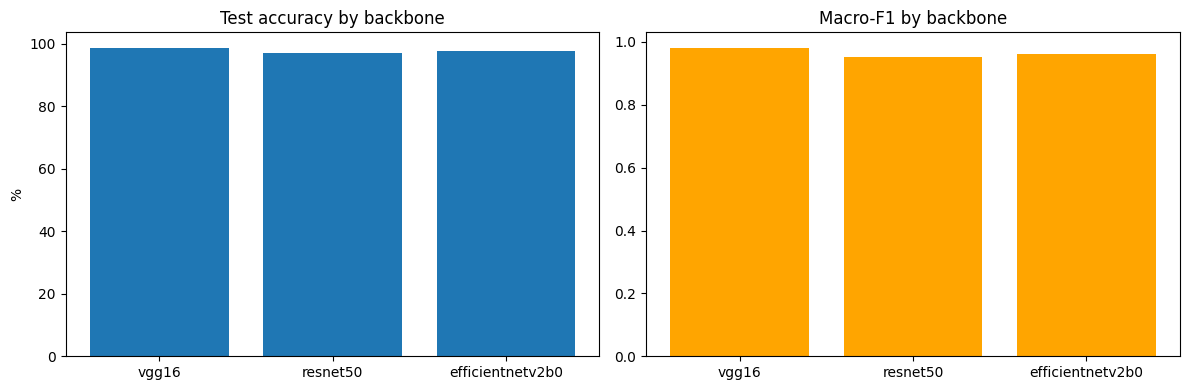

In [18]:
# %% [Cell 17] --------------------------------------------------------------------------------
# ------------------------------- RUN THE BACKBONE COMPARISON -----------------------------------
# Shorter schedule than the main run (this is 3x the training cost) — raise these if you have the
# Kaggle GPU-hour budget for a tighter comparison.
CFG.COMPARISON_PHASE1_EPOCHS = 15
CFG.COMPARISON_PHASE2_EPOCHS = 15
 
comparison_backbones = ["vgg16", "resnet50", "efficientnetv2b0"]
comparison_results = []
 
for backbone_name in comparison_backbones:
    print(f"\n=== Training backbone: {backbone_name} ===")
    preprocess_fn = BACKBONE_REGISTRY[backbone_name]["preprocess"]
 
    cb_train_ds = make_dataset_generic(CFG.TRAIN_DIR, CFG.IMG_SIZE, CFG.BATCH_SIZE,
                                        training=True, preprocess_fn=preprocess_fn)
    cb_val_ds = make_dataset_generic(CFG.VAL_DIR, CFG.IMG_SIZE, CFG.BATCH_SIZE,
                                      training=False, preprocess_fn=preprocess_fn)
 
    cb_model, cb_backbone = build_model_generic(backbone_name, CFG.NUM_CLASSES,
                                                 use_spatial_attention=True, freeze_backbone=True)
    cb_model.compile(optimizer=optimizers.RMSprop(CFG.PHASE1_LR),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb_model.fit(cb_train_ds, validation_data=cb_val_ds, epochs=CFG.COMPARISON_PHASE1_EPOCHS,
                 callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                                     restore_best_weights=True, mode="max")])
 
    cb_backbone = set_fine_tune_layers(cb_backbone, last_n=CFG.FINE_TUNE_LAST_N_LAYERS)
    cb_model.compile(optimizer=optimizers.RMSprop(CFG.PHASE2_LR),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb_model.fit(cb_train_ds, validation_data=cb_val_ds, epochs=CFG.COMPARISON_PHASE2_EPOCHS,
                 callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=CFG.EARLY_STOP_PATIENCE,
                                                     restore_best_weights=True, mode="max")])
 
    metrics_dict, _, _ = evaluate_model_on_test(cb_model, CFG.TEST_DIR, CFG.IMG_SIZE,
                                                 CFG.BATCH_SIZE, preprocess_fn)
    n_params = cb_model.count_params()
    flops_b = get_flops(cb_model)
    latency_ms = measure_latency_ms(cb_model, CFG.IMG_SIZE)
 
    comparison_results.append({
        "backbone": backbone_name,
        "accuracy_pct": round(metrics_dict["accuracy"] * 100, 2),
        "macro_f1": round(metrics_dict["macro_f1"], 4),
        "micro_f1": round(metrics_dict["micro_f1"], 4),
        "weighted_f1": round(metrics_dict["weighted_f1"], 4),
        "params_M": round(n_params / 1e6, 2),
        "flops_GB": None if flops_b is None else round(flops_b, 2),
        "latency_ms": round(latency_ms, 1),
    })
 
    del cb_model, cb_backbone, cb_train_ds, cb_val_ds
    keras.backend.clear_session()  # free GPU memory before the next backbone
 
comparison_df = pd.DataFrame(comparison_results)
print("\n=== Backbone comparison (Table-2-style) ===")
print(comparison_df.to_string(index=False))
comparison_df.to_csv(os.path.join(CFG.OUTPUT_DIR, "backbone_comparison.csv"), index=False)
 
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(comparison_df["backbone"], comparison_df["accuracy_pct"])
ax[0].set_title("Test accuracy by backbone")
ax[0].set_ylabel("%")
ax[1].bar(comparison_df["backbone"], comparison_df["macro_f1"], color="orange")
ax[1].set_title("Macro-F1 by backbone")
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "backbone_comparison.png"), dpi=150)
plt.show()

In [19]:
# %% [Cell 18] --------------------------------------------------------------------------------
# ------------------------------- CMPD268: CLASS IMBALANCE ANALYSIS -----------------------------
# CMPD268 (Li et al., 2022a) is the dataset with 4-70 images/class (paper's Fig. 6) — this is
# where macro-F1 has real headroom, because rare classes get out-voted by common ones under a
# plain cross-entropy loss. UPDATE CFG268.DATA_ROOT to your actual CMPD268 Kaggle dataset path.
class CFG268:
    DATA_ROOT = "/kaggle/input/datasets/<your-username>/<your-cmpd268-slug>/Split"  # <-- UPDATE THIS
    TRAIN_DIR = os.path.join(DATA_ROOT, "train")
    VAL_DIR = os.path.join(DATA_ROOT, "val")
    TEST_DIR = os.path.join(DATA_ROOT, "test")
 
if not os.path.isdir(CFG268.TRAIN_DIR):
    print(f"[!] CFG268.DATA_ROOT does not exist yet: {CFG268.DATA_ROOT}\n"
          f"    Update the path above to your CMPD268 dataset before running Cells 18-21.")
else:
    class_names_268 = sorted(os.listdir(CFG268.TRAIN_DIR))
    CFG268.NUM_CLASSES = len(class_names_268)
    class_counts = {c: len(os.listdir(os.path.join(CFG268.TRAIN_DIR, c))) for c in class_names_268}
    counts_arr = np.array(list(class_counts.values()))
 
    print(f"CMPD268 train classes: {CFG268.NUM_CLASSES}")
    print(f"Images/class — min: {counts_arr.min()}, max: {counts_arr.max()}, "
          f"mean: {counts_arr.mean():.1f}, std: {counts_arr.std():.1f}")
 
    plt.figure(figsize=(12, 4))
    plt.bar(range(len(counts_arr)), sorted(counts_arr, reverse=True))
    plt.title("CMPD268 — images per class (train split), sorted")
    plt.xlabel("Class rank")
    plt.ylabel("Number of images")
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, "cmpd268_class_distribution.png"), dpi=150)
    plt.show()
 
    # Balanced class weights (sklearn's standard "n_samples / (n_classes * n_samples_per_class)")
    labels_expanded = np.concatenate([[i] * c for i, c in enumerate(counts_arr)])
    class_weights_arr = compute_class_weight("balanced", classes=np.arange(len(counts_arr)),
                                              y=labels_expanded)
    class_weight_dict = {i: float(w) for i, w in enumerate(class_weights_arr)}
    print(f"Class weight range: [{min(class_weight_dict.values()):.2f}, "
          f"{max(class_weight_dict.values()):.2f}] "
          f"(rarest class gets ~{max(class_weight_dict.values())/min(class_weight_dict.values()):.1f}x "
          f"more weight than the most common)")
 

[!] CFG268.DATA_ROOT does not exist yet: /kaggle/input/datasets/<your-username>/<your-cmpd268-slug>/Split
    Update the path above to your CMPD268 dataset before running Cells 18-21.


In [20]:
# %% [Cell 19] --------------------------------------------------------------------------------
# ------------------------------- FOCAL LOSS (for the imbalance experiment) ---------------------
# Standard sparse-label focal loss: down-weights easy/well-classified examples (probs near 1)
# so training focuses on hard/rare examples, which is exactly the failure mode plain CE has on
# CMPD268's long tail. Optional per-class alpha weighting stacks with the focal term.
def sparse_categorical_focal_loss(gamma=2.0, class_weights=None):
    weights_tensor = None
    if class_weights is not None:
        weights_tensor = tf.constant([class_weights[i] for i in range(len(class_weights))],
                                      dtype=tf.float32)
 
    def loss_fn(y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32),
                                   keras.backend.epsilon(), 1.0 - keras.backend.epsilon())
        probs = tf.gather(y_pred, y_true, axis=1, batch_dims=1)
        focal_term = tf.pow(1.0 - probs, gamma)
        ce = -tf.math.log(probs)
        loss = focal_term * ce
        if weights_tensor is not None:
            alpha = tf.gather(weights_tensor, y_true)
            loss = loss * alpha
        return loss
    return loss_fn
 

In [21]:
# %% [Cell 20] --------------------------------------------------------------------------------
# ------------------------------- TRAIN 4 VARIANTS ON CMPD268 -----------------------------------
# baseline_CE          = paper's exact approach (unweighted cross-entropy) — the number to beat
# class_weighted_CE    = plain CE + sklearn "balanced" class weights
# focal_loss           = focal loss, gamma=2, no class weights
# focal_loss_weighted  = focal loss + class weights stacked
# All four use the SAME backbone (EfficientNetV2B0+SA, the paper's best) and SAME schedule, so the
# only thing that changes between rows is the loss/weighting strategy — a clean ablation.
def train_and_eval_variant(loss_obj, class_weight_arg, tag):
    print(f"\n--- CMPD268 variant: {tag} ---")
    preprocess_fn = BACKBONE_REGISTRY["efficientnetv2b0"]["preprocess"]
    m, bb = build_model_generic("efficientnetv2b0", CFG268.NUM_CLASSES,
                                 use_spatial_attention=True, freeze_backbone=True)
    tr_ds = make_dataset_generic(CFG268.TRAIN_DIR, CFG.IMG_SIZE, CFG.BATCH_SIZE,
                                  training=True, preprocess_fn=preprocess_fn)
    va_ds = make_dataset_generic(CFG268.VAL_DIR, CFG.IMG_SIZE, CFG.BATCH_SIZE,
                                  training=False, preprocess_fn=preprocess_fn)
 
    m.compile(optimizer=optimizers.RMSprop(CFG.PHASE1_LR), loss=loss_obj, metrics=["accuracy"])
    m.fit(tr_ds, validation_data=va_ds, epochs=CFG.COMPARISON_PHASE1_EPOCHS,
          class_weight=class_weight_arg,
          callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                              restore_best_weights=True, mode="max")])
 
    bb = set_fine_tune_layers(bb, last_n=CFG.FINE_TUNE_LAST_N_LAYERS)
    m.compile(optimizer=optimizers.RMSprop(CFG.PHASE2_LR), loss=loss_obj, metrics=["accuracy"])
    m.fit(tr_ds, validation_data=va_ds, epochs=CFG.COMPARISON_PHASE2_EPOCHS,
          class_weight=class_weight_arg,
          callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=CFG.EARLY_STOP_PATIENCE,
                                              restore_best_weights=True, mode="max")])
 
    metrics_dict, _, _ = evaluate_model_on_test(m, CFG268.TEST_DIR, CFG.IMG_SIZE,
                                                 CFG.BATCH_SIZE, preprocess_fn)
    metrics_dict["variant"] = tag
    keras.backend.clear_session()
    return metrics_dict
 
if os.path.isdir(CFG268.TRAIN_DIR):
    imbalance_results = [
        train_and_eval_variant("sparse_categorical_crossentropy", None, "baseline_CE"),
        train_and_eval_variant("sparse_categorical_crossentropy", class_weight_dict, "class_weighted_CE"),
        train_and_eval_variant(sparse_categorical_focal_loss(gamma=2.0), None, "focal_loss"),
        train_and_eval_variant(sparse_categorical_focal_loss(gamma=2.0, class_weights=class_weight_dict),
                                None, "focal_loss_weighted"),
    ]
    imbalance_df = pd.DataFrame(imbalance_results)[
        ["variant", "accuracy", "macro_f1", "micro_f1", "weighted_f1"]
    ]
    baseline_macro = imbalance_df.loc[imbalance_df.variant == "baseline_CE", "macro_f1"].values[0]
    imbalance_df["macro_f1_gain_over_baseline_pct"] = (
        (imbalance_df["macro_f1"] - baseline_macro) / baseline_macro * 100
    ).round(2)
    print("\n=== CMPD268 imbalance-handling comparison ===")
    print(imbalance_df.to_string(index=False))
    imbalance_df.to_csv(os.path.join(CFG.OUTPUT_DIR, "cmpd268_imbalance_comparison.csv"), index=False)
else:
    print("Skipping Cell 20 — CFG268.DATA_ROOT not found. Update the path in Cell 18 first.")
 
 


Skipping Cell 20 — CFG268.DATA_ROOT not found. Update the path in Cell 18 first.


In [22]:
# %% [Cell 21] --------------------------------------------------------------------------------
# ------------------------------- PLOT: MACRO-F1 IMPROVEMENT ON CMPD268 -------------------------
if os.path.isdir(CFG268.TRAIN_DIR):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(imbalance_df["variant"], imbalance_df["macro_f1"],
                    color=["gray", "steelblue", "steelblue", "seagreen"])
    plt.axhline(baseline_macro, color="gray", linestyle="--", linewidth=1, label="baseline_CE")
    plt.ylabel("Macro-F1 (test set)")
    plt.title("CMPD268 — macro-F1 by imbalance-handling strategy")
    plt.xticks(rotation=15)
    for bar, gain in zip(bars, imbalance_df["macro_f1_gain_over_baseline_pct"]):
        label = f"+{gain:.1f}%" if gain > 0 else f"{gain:.1f}%"
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, label,
                  ha="center", fontsize=9)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, "cmpd268_macro_f1_improvement.png"), dpi=150)
    plt.show()
 
    best_variant = imbalance_df.loc[imbalance_df["macro_f1"].idxmax()]
    print(f"\nBest variant: {best_variant['variant']} "
          f"— macro-F1 {best_variant['macro_f1']:.4f} "
          f"({best_variant['macro_f1_gain_over_baseline_pct']:+.1f}% vs baseline_CE)")
 


--- SA ablation: no_spatial_attention (efficientnetv2b0, spatial_attention=False) ---
Found 4609 files belonging to 568 classes.
Found 1333 files belonging to 568 classes.
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


I0000 00:00:1787722470.045567     245 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


73/73 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.1512 - loss: 5.2946 - val_accuracy: 0.4411 - val_loss: 4.8089
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.4982 - loss: 2.7603 - val_accuracy: 0.6954 - val_loss: 3.4968
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.7047 - loss: 1.7269 - val_accuracy: 0.8237 - val_loss: 2.3608
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8310 - loss: 1.1132 - val_accuracy: 0.8957 - val_loss: 1.5211
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9039 - loss: 0.7439 - val_accuracy: 0.9205 - val_loss: 1.0115
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9419 - loss: 0.5125 - val_accuracy: 0.9430 - val_loss: 0.6924
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9655 - loss: 0.3511 - val_accuracy: 0.9527 - val_loss: 0.5125
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9764 - loss: 0.2538 - val_accuracy: 0.9565 - val_loss: 0.

2026-08-26 05:40:49.344708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:40:49.495249: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:40:50.953076: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:40:51.094266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.0663 - loss: 6.1881

...

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.0675 - loss: 6.1757

2026-08-26 05:41:43.414958: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:41:43.561347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:41:44.982011: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:41:45.122178: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


73/73 ━━━━━━━━━━━━━━━━━━━━ 79s 681ms/step - accuracy: 0.1525 - loss: 5.2867 - val_accuracy: 0.3991 - val_loss: 5.1631
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.4940 - loss: 2.7924 - val_accuracy: 0.6857 - val_loss: 3.8251
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.7073 - loss: 1.7337 - val_accuracy: 0.8312 - val_loss: 2.6976
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.8512 - loss: 1.0617 - val_accuracy: 0.8867 - val_loss: 1.6496
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9032 - loss: 0.7199 - val_accuracy: 0.9377 - val_loss: 1.0974
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9499 - loss: 0.4726 - val_accuracy: 0.9467 - val_loss: 0.6781
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9690 - loss: 0.3174 - val_accuracy: 0.9550 - val_loss: 0.4479
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9764 - loss: 0.2328 - val_accuracy: 0.9632 - val_loss: 

2026-08-26 05:45:38.573769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:45:38.707568: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:45:40.105286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:45:40.246698: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



=== Spatial attention ablation (efficientnetv2b0) ===
               variant  accuracy  macro_f1  micro_f1  weighted_f1  params_M  macro_f1_gain_from_SA_pct
  no_spatial_attention  0.974582  0.959795  0.974582     0.971429     6.652                       0.00
with_spatial_attention  0.972102  0.958242  0.972102     0.969419     6.652                      -0.16


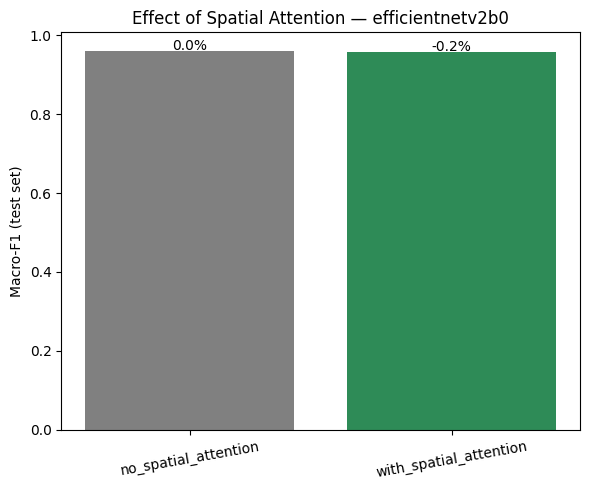


Spatial attention changed macro-F1 by -0.16% (within noise for a 30-epoch run — consider a longer schedule or repeated seeds before claiming it matters).


In [9]:
# %% [Cell 22] --------------------------------------------------------------------------------
# ------------------------------- SPATIAL ATTENTION ABLATION ------------------------------------
# Isolates ONE variable: same backbone, same data, same two-phase schedule — only difference is
# whether the SpatialAttention module (Eq. 7-9) sits between the backbone and the pooling head.
# This is the direct test of whether the paper's headline contribution is actually earning its
# keep, and it's the one comparison missing from everything run so far.
CFG.ABLATION_BACKBONE = "efficientnetv2b0"   # paper's chosen backbone; swap to "vgg16" to also
                                              # check whether SA helps the backbone that actually
                                              # won your Cell 17 comparison
CFG.ABLATION_PHASE1_EPOCHS = 15
CFG.ABLATION_PHASE2_EPOCHS = 15
 
def train_and_eval_sa_variant(backbone_name, use_spatial_attention, tag):
    print(f"\n--- SA ablation: {tag} ({backbone_name}, spatial_attention={use_spatial_attention}) ---")
    preprocess_fn = BACKBONE_REGISTRY[backbone_name]["preprocess"]
 
    tr_ds = make_dataset_generic(CFG.TRAIN_DIR, CFG.IMG_SIZE, CFG.BATCH_SIZE,
                                  training=True, preprocess_fn=preprocess_fn)
    va_ds = make_dataset_generic(CFG.VAL_DIR, CFG.IMG_SIZE, CFG.BATCH_SIZE,
                                  training=False, preprocess_fn=preprocess_fn)
 
    m, bb = build_model_generic(backbone_name, CFG.NUM_CLASSES,
                                 use_spatial_attention=use_spatial_attention, freeze_backbone=True)
 
    m.compile(optimizer=optimizers.RMSprop(CFG.PHASE1_LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(tr_ds, validation_data=va_ds, epochs=CFG.ABLATION_PHASE1_EPOCHS,
          callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                              restore_best_weights=True, mode="max")])
 
    bb = set_fine_tune_layers(bb, last_n=CFG.FINE_TUNE_LAST_N_LAYERS)
    m.compile(optimizer=optimizers.RMSprop(CFG.PHASE2_LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(tr_ds, validation_data=va_ds, epochs=CFG.ABLATION_PHASE2_EPOCHS,
          callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=CFG.EARLY_STOP_PATIENCE,
                                              restore_best_weights=True, mode="max")])
 
    metrics_dict, _, _ = evaluate_model_on_test(m, CFG.TEST_DIR, CFG.IMG_SIZE,
                                                 CFG.BATCH_SIZE, preprocess_fn)
    n_params = m.count_params()
    metrics_dict.update({"variant": tag, "params_M": round(n_params / 1e6, 3)})
    keras.backend.clear_session()
    return metrics_dict
 
sa_ablation_results = [
    train_and_eval_sa_variant(CFG.ABLATION_BACKBONE, False, "no_spatial_attention"),
    train_and_eval_sa_variant(CFG.ABLATION_BACKBONE, True, "with_spatial_attention"),
]
sa_df = pd.DataFrame(sa_ablation_results)[
    ["variant", "accuracy", "macro_f1", "micro_f1", "weighted_f1", "params_M"]
]
no_sa_macro = sa_df.loc[sa_df.variant == "no_spatial_attention", "macro_f1"].values[0]
sa_df["macro_f1_gain_from_SA_pct"] = ((sa_df["macro_f1"] - no_sa_macro) / no_sa_macro * 100).round(2)
 
print(f"\n=== Spatial attention ablation ({CFG.ABLATION_BACKBONE}) ===")
print(sa_df.to_string(index=False))
sa_df.to_csv(os.path.join(CFG.OUTPUT_DIR, f"spatial_attention_ablation_{CFG.ABLATION_BACKBONE}.csv"),
             index=False)
 
plt.figure(figsize=(6, 5))
bars = plt.bar(sa_df["variant"], sa_df["macro_f1"], color=["gray", "seagreen"])
plt.ylabel("Macro-F1 (test set)")
plt.title(f"Effect of Spatial Attention — {CFG.ABLATION_BACKBONE}")
plt.xticks(rotation=10)
for bar, gain in zip(bars, sa_df["macro_f1_gain_from_SA_pct"]):
    label = f"+{gain:.1f}%" if gain > 0 else f"{gain:.1f}%"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, label, ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"spatial_attention_ablation_{CFG.ABLATION_BACKBONE}.png"), dpi=150)
plt.show()
 
sa_gain = sa_df.loc[sa_df.variant == "with_spatial_attention", "macro_f1_gain_from_SA_pct"].values[0]
print(f"\nSpatial attention changed macro-F1 by {sa_gain:+.2f}% "
      f"({'a real, if modest, contribution' if abs(sa_gain) > 1 else 'within noise for a 30-epoch run — consider a longer schedule or repeated seeds before claiming it matters'}).")
 